In [10]:
from pathlib import Path
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    print("Ejecución en local")

# TENER EN CUENTA DESDE DÓNDE ESTAMOS EJECUTANDO PARA ENCONTRAR EL REQUIREMENTS
BASE_PATH = Path("/content/drive/MyDrive/TFMCode") if IN_COLAB else Path("..").resolve()

if IN_COLAB:
    drive.mount('/content/drive')
    print("Ejecución en colab")

    %pip install -r "{BASE_PATH}/requirements.txt"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ejecución en colab


In [ ]:
# imports
# librerías
from sklearn.neighbors import KNeighborsRegressor
import pandas as pd
import numpy as np
import sys
from pathlib import Path
# útiles
UTILS_PATH = BASE_PATH / "utils"
sys.path.append(str(UTILS_PATH))
# data
DATA_PATH = BASE_PATH / "data"
sys.path.append(str(DATA_PATH))
# clase y función del archivo py de la carpeta utils
from protocolo_evaluacion import (PerformanceEvaluator, run_benchmarked_inference)

# Implementación del sistema de referencia kNN

En este notebook implementaremos el código para conseguir los sistemas de referencia más óptimos posibles para los dos datasets MAN1 y UJI1. El modelo kNN se compone de tres elementos principales, que son, por orden de importancia: el valor de k, la función de distancia y la representación de los datos. Para conseguir la combinación más óptima de estos tres parámetros realizaremos una búsqueda de rejilla.

La función tune_knn_baseline realiza la búsqueda de rejilla para encontrar los mejores hiperparámetros del kNN en cada dataset. La búsqueda se hace entre los valores impares de k en el rango [1,15] y las métricas euclídea y manhattan

In [ ]:
def tune_knn_baseline(dataset_name, x_train, y_train, x_test, y_test, iterations):
    """
    Realiza una búsqueda de los mejores hiperparámetros para el baseline k-NN.
    y_train/y_test deben contener todas las columnas necesarias (x, y, [piso, edificio])
    """
    k_values = [1, 3, 5, 7, 9, 11, 13, 15]
    metrics = ['euclidean', 'manhattan']

    best_results = None
    best_mae = float('inf')
    all_logs = []

    print(f"Búsqueda rejilla para el dataset: {dataset_name}")

    for metric in metrics:
        for k in k_values:
            # instanciamos el modelo kNN
            knn = KNeighborsRegressor(n_neighbors=k, metric=metric, weights='uniform')

            # ejecutamos la inferencia con el número de iteraciones indicado
            # llamamos a la función importada de utils
            # retorna las predicciones, el tiempo medio y el tiempo estándar de inferencia
            y_pred, avg_time, std_time = run_benchmarked_inference(knn.fit(x_train, y_train), x_test, iterations=iterations)

            # instanciamos un objeto de la clase evaluador importada de utils
            evaluator = PerformanceEvaluator(dataset_name)

            if dataset_name == "UJI1":
                # en UJI1 los índices 0 y 1 son x e y; el índice 2 es el piso; el índice 3 es el edificio
                # redondeamos
                y_pred_labels = np.round(y_pred[:, 2:4])
                # llamamos al método del objeto
                # para UJI1 retorna accuracy de piso y edificio, MAE en 2D, percentiles 75 y 95
                res = evaluator.calculate_precision(y_test[:, 0:2], y_pred[:, 0:2],
                                                   building_floor_true=y_test[:, 2:4],
                                                   building_floor_pred=y_pred_labels)
            else:
                # para MAN1 retorna MAE en 2D, percentiles 75 y 95
                res = evaluator.calculate_precision(y_test, y_pred)

            # registra los resultados de eficiencia
            # añade a la lista de logs toda la información
            res['k'] = k
            res['metric'] = metric
            res['MTQ_ms'] = (avg_time / len(x_test)) * 1000

            all_logs.append(res)

            # criterio de selección del mejor modelo: el menor MAE (en UJI1, MAE cuando se acierta edificio/piso)
            if res['MAE_2D'] < best_mae:
                best_mae = res['MAE_2D']
                best_results = res

            # imprime información de la iteración en curso
            print(f"Prueba: k={k}, métrica={metric} --> MAE: {res['MAE_2D']:.2f}m")

    # retorna la información del método de cálculo de precisión en forma de df y los resultados del mejor modelo
    return pd.DataFrame(all_logs), best_results

## MAN1

Comenzamos a modelar nuestros sistemas de referencia para cada dataset. Procedemos a hacer el grid search, en primer lugar, con el dataset MAN1

In [13]:
# importamos los archivos de train y test de RSS y de coordenadas
man1_train_rss = pd.read_csv(DATA_PATH / "clean" / "MAN1" / "MAN1_trnrss_clean.csv", header=None)
man1_test_rss = pd.read_csv(DATA_PATH / "clean" / "MAN1" / "MAN1_tstrss_clean.csv", header=None)
man1_train_crd = pd.read_csv(DATA_PATH / "clean" / "MAN1" / "MAN1_trncrd_clean.csv", header=None)
man1_test_crd = pd.read_csv(DATA_PATH / "clean" / "MAN1" / "MAN1_tstcrd_clean.csv", header=None)

In [ ]:
# llamamos a la función para afinar el kNN
# almacenamos en variables el retorno de la función: la información del cálculo de la precisión de todas las iteraciones y de la mejor configuración
# indicamos el número de iteraciones a probar
man1_log_df, man1_best_config = tune_knn_baseline("MAN1", man1_train_rss, man1_train_crd, man1_test_rss, man1_test_crd, iterations=5)

--- Optimizando Baseline para MAN1 ---
Iniciando benchmark: 5 iteraciones...
Tiempo medio: 37.39 ms, desviación: 6.12 ms
Prueba: k=1, Métrica=euclidean -> MAE: 2.85m
Iniciando benchmark: 5 iteraciones...
Tiempo medio: 34.07 ms, desviación: 0.99 ms
Prueba: k=3, Métrica=euclidean -> MAE: 2.52m
Iniciando benchmark: 5 iteraciones...
Tiempo medio: 34.80 ms, desviación: 0.30 ms
Prueba: k=5, Métrica=euclidean -> MAE: 2.34m
Iniciando benchmark: 5 iteraciones...
Tiempo medio: 34.84 ms, desviación: 1.14 ms
Prueba: k=7, Métrica=euclidean -> MAE: 2.30m
Iniciando benchmark: 5 iteraciones...
Tiempo medio: 36.84 ms, desviación: 1.41 ms
Prueba: k=9, Métrica=euclidean -> MAE: 2.27m
Iniciando benchmark: 5 iteraciones...
Tiempo medio: 37.76 ms, desviación: 0.75 ms
Prueba: k=11, Métrica=euclidean -> MAE: 2.27m
Iniciando benchmark: 5 iteraciones...
Tiempo medio: 46.79 ms, desviación: 7.33 ms
Prueba: k=13, Métrica=euclidean -> MAE: 2.26m
Iniciando benchmark: 5 iteraciones...
Tiempo medio: 40.33 ms, desviaci

Una vez que hemos llamado a la función para afinar el kNN podemos ver la información sobre las iteraciones realizadas y sobre la mejor combinación de hiperparámetros encontrada.

In [ ]:
# imprimimos la mejor configuración encontrada
print("Mejor modelo encontrado para MAN1. Métricas de precisión y mejores hiperparámetros")
print(man1_best_config)

# imprimimos df con la información sobre las iteraciones, ordenada de mejor MAE en 2D a peor
man1_log_df.sort_values(by='MAE_2D', ascending=True)

--- MEJOR MODELO ENCONTRADO ---
{'MAE_2D': 2.1573793196057105, 'P75': 2.9737586299335006, 'P95': 4.6940073349266775, 'k': 15, 'metric': 'manhattan', 'MTQ_ms': 0.4163807371388311}


,MAE_2D,P75,P95,k,metric,MTQ_ms
15,2.157379,2.973759,4.694007,15,manhattan,0.416381
13,2.173722,2.881539,4.637918,11,manhattan,0.620911
12,2.192849,2.923038,4.604190,9,manhattan,0.618049
14,2.193223,2.994221,4.655502,13,manhattan,0.485501
11,2.215664,2.998997,4.826209,7,manhattan,0.488540
10,2.257887,3.065923,5.063099,5,manhattan,0.399236
6,2.262949,3.145199,4.974516,13,euclidean,0.101714
5,2.266056,3.174762,4.927744,11,euclidean,0.082082
4,2.269449,3.035346,5.125196,9,euclidean,0.080089
7,2.270413,3.077549,5.014729,15,euclidean,0.087679


Una vez que hemos obtenido la mejor combinación de hiperparámetros para MAN1 podemos entrenar a nuestro modelo que servirá como sistema de referencia definitivo para MAN1

In [ ]:
# almacenamos en variables los mejores valores de k y de métrica
best_k = man1_best_config['k']
best_metric = man1_best_config['metric']

# instanciamos el modelo configurado con los mejores hiperparámetros
knn_best = KNeighborsRegressor(n_neighbors=best_k, metric=best_metric, weights='uniform')

# entrenamos
knn_best.fit(man1_train_rss, man1_train_crd)

# predecimos test
y_pred_best = knn_best.predict(man1_test_rss)

# y_test es el dataframe original de coordenadas de test
y_test = man1_test_crd.values

Con el modelo con los mejores hiperparámetros posibles entrenado y las predicciones sobre test hechas, podemos sacar toda la información sobre métricas que necesitamos para establecer el rendimiento de nuestro sistema de referencia que tendremos que batir en futuros modelos.

--- MÉTRICAS FINALES DEL BASELINE (MAN1) ---
MAE_2D: 2.1574
P75: 2.9738
P95: 4.6940

Generando Función de Distribución Acumulada (CDF)...


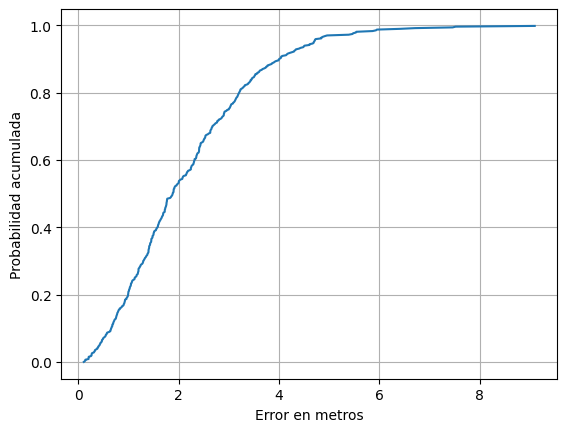

In [ ]:
# instanciamos un objeto de la clase evaluador
final_evaluator = PerformanceEvaluator("MAN1")

# calculamos todas las métricas de precisión con las predicciones sobre test del modelo final
final_metrics = final_evaluator.calculate_precision(y_test, y_pred_best)

# imprimimos todas las métricas finales
print("MÉTRICAS FINALES DEL BASELINE DE MAN1")
for metrica, valor in final_metrics.items():
    print(f"{metrica}: {valor:.4f}")

# Generamos la visualización de la curva de error
print("\nCurva de función de distribución acumulada")
final_evaluator.plot_cdf()